In [8]:
!pip install arch

In [65]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from scipy import stats

from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.tsa.stattools import adfuller


# -----------------------
# CONFIG
# -----------------------
H = 22                    # period in which we forcast daily volatility
LOOKBACK = 60             # lookback window for NN sequence models
TEST_SIZE = 0.2           # fraction of data for test split
SEEDS = [11, 22, 33, 44, 55]  # 5 runs

EPS = 1e-12

def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def realized_var_h(returns: pd.Series, h: int) :
    r2 = returns**2
    rv = r2.rolling(h).sum().shift(-(h-1))
    return np.sqrt(rv/h)
    return rv



def metrics_vol(y_true_vol, y_pred_vol, eps=1e-8):
    y = np.asarray(y_true_vol, dtype=float)
    f = np.asarray(y_pred_vol, dtype=float)

    # safety
    y = np.maximum(y, eps)
    f = np.maximum(f, eps)

    err = y - f
    mse  = float(np.mean(err**2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(err)))

    rel = 1.0 - (f / y)          # (1 - vhat / RV)
    hmae = float(np.mean(np.abs(rel)))
    hmse = float(np.mean(rel**2))

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "HMAE": hmae,
        "HMSE": hmse,
    }




In [11]:
EPS = 1e-12

df = pd.read_csv(r'wheat_rolling_futures.csv')

# --- Underlying returns ---
df["ret"] = 100 * np.log(df["PX_LAST"]).diff()
df["abs_ret"] = df["ret"].abs()
df["ret2"] = df["ret"] ** 2
df["log_ret2"] = np.log(df["ret2"] + EPS)

df["gold_ret"] = 100 * np.log(df["PX_GOLD"]).diff()

df["prod_growth"] = np.log(df["WUSETWPR"]).diff()

feat_cols = ["ret", "abs_ret", "ret2", "log_ret2", "gold_ret", "prod_growth"]

df_feat = df[feat_cols].dropna()

returns = df['ret'].dropna()

print(df_feat.head())

        ret   abs_ret      ret2  log_ret2  gold_ret  prod_growth
1 -2.363160  2.363160  5.584527  1.720000  0.163883          0.0
2  1.777585  1.777585  3.159809  1.150512 -0.163883          0.0
3 -0.320856  0.320856  0.102949 -2.273526  0.879292          0.0
4 -1.293819  1.293819  1.673967  0.515196 -0.200301          0.0
5  1.881270  1.881270  3.539178  1.263894 -0.678992          0.0


In [12]:

def run_statistical_tests(series):
    mean_val = np.mean(series)
    std_dev = np.std(series)

    # Shape Tests
    skew_val = skew(series)
    kurt_val = kurtosis(series)

    jb_stat, jb_p = jarque_bera(series)

    adf_result = adfuller(series)

    args = [mean_val, std_dev, skew_val, kurt_val, jb_stat, jb_p, adf_result[0]]

    return args

df1 = pd.DataFrame([run_statistical_tests(df['PX_LAST']),run_statistical_tests(df['PX_GOLD'].dropna()),run_statistical_tests(df['WUSETWPR'].dropna()),run_statistical_tests(df['ret'].dropna())],columns=['Mean', 'Std Dev', 'Skew', 'Kurtosis', 'Jarque-Bera', 'Jarque_bera(p val)', 'ADF'])
df1.index = ['wheat_returns', 'gold_returns', 'production_growth', 'log_returns']
display(df1)

,Mean,Std Dev,Skew,Kurtosis,Jarque-Bera,Jarque_bera(p val),ADF
wheat_returns,517.881768,185.094724,0.722798,0.342481,718.484260,9.618895e-157,-2.645897
gold_returns,1100.621903,741.203364,1.049656,1.652647,2323.832347,0.000000e+00,4.789214
production_growth,2074.353812,248.363670,0.043663,-0.771954,196.476892,2.165633e-43,-2.749938
log_returns,0.001255,1.818936,0.207120,2.224593,1666.692983,0.000000e+00,-87.359893


In [62]:
# split into train and test
y_var = realized_var_h(returns, H) # target variable

df = pd.DataFrame({"r": returns, "y_var": y_var}).dropna()
returns_clean = df["r"]
y_var_clean = df["y_var"]

# train/test split by time (no shuffle)
n = len(df)
test_n = int(np.ceil(TEST_SIZE * n))
train_df = df.iloc[:-test_n].copy()
test_df  = df.iloc[-test_n:].copy()

r_train = train_df["r"]
r_test  = test_df["r"]

y_train = train_df["y_var"]
y_test  = test_df["y_var"]

print("Rows:", n, "| Train:", len(train_df), "| Test:", len(test_df))
print("Train range:", train_df.index.min(), "->", train_df.index.max())
print("Test  range:", test_df.index.min(), "->", test_df.index.max())


Rows: 7791 | Train: 6232 | Test: 1559
Train range: 1 -> 6232
Test  range: 6233 -> 7791


#Econometric Models

GARCH(1,1) — Daily-Equivalent Volatility Results:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.350076,0.591672,0.394645,0.228325,0.090079,11
1,0.350076,0.591672,0.394645,0.228325,0.090079,22
2,0.350076,0.591672,0.394645,0.228325,0.090079,33
3,0.350076,0.591672,0.394645,0.228325,0.090079,44
4,0.350076,0.591672,0.394645,0.228325,0.090079,55



Mean / Std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.350076,0.591672,0.394645,0.228325,0.090079
std,0.000000,0.000000,0.000000,0.000000,0.000000


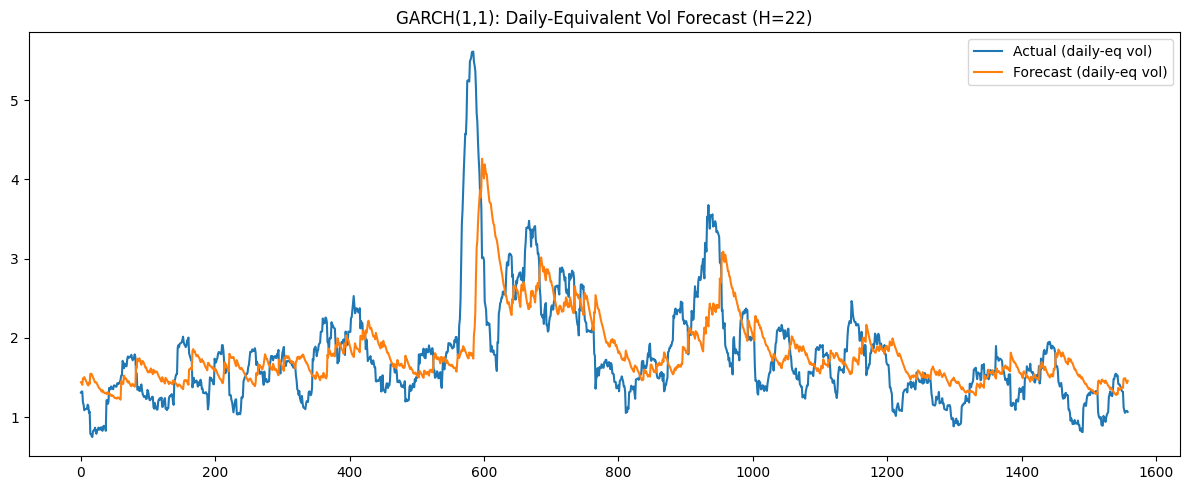

In [66]:
# ======
# GARCH
# ======


garch_runs = []
garch_preds = []

garch_feat_list = []

for seed in SEEDS:
    set_all_seeds(seed)

    am = arch_model(
        r_train,
        vol="GARCH", p=1, q=1,
        mean="Constant",
        dist="Normal",
        rescale=True
    )
    res = am.fit(disp="off")

    p = res.params
    mu = float(p.get("mu", 0.0))
    omega = float(p["omega"])
    alpha = float(p[[k for k in p.index if k.startswith("alpha[")][0]])
    beta  = float(p[[k for k in p.index if k.startswith("beta[")][0]])

    ab = min(alpha + beta, 0.999)

    feat_var_train = pd.Series(
        (res.conditional_volatility**2).values,
        index=r_train.index,
        dtype=float
    )

    sigma2_prev = float(res.conditional_volatility.iloc[-1] ** 2)

    pred_vol_series = []
    idx_series = []

    feat_var_test = []

    for tstamp, r_t in r_test.items():

        sigma2_k = sigma2_prev
        fcast_var = []
        for _ in range(H):
            sigma2_k = omega + ab * sigma2_k
            fcast_var.append(sigma2_k)

        pred_var_H = np.sum(fcast_var)
        pred_vol = np.sqrt(pred_var_H / H)

        pred_vol_series.append(pred_vol)
        idx_series.append(tstamp)

        eps_t = float(r_t - mu)
        sigma2_prev = omega + alpha * (eps_t**2) + beta * sigma2_prev
        sigma2_prev = max(sigma2_prev, EPS)

        feat_var_test.append(sigma2_prev)

    pred_vol = pd.Series(pred_vol_series, index=pd.Index(idx_series), name=f"seed_{seed}")
    garch_preds.append(pred_vol)

    y_true_vol = y_test.loc[pred_vol.index].values
    m = metrics_vol(y_true_vol, pred_vol.values)
    m["seed"] = seed
    garch_runs.append(m)

    feat_var = pd.concat(
        [feat_var_train,
         pd.Series(feat_var_test, index=pd.Index(idx_series), dtype=float)]
    ).clip(lower=EPS)

    garch_feat_list.append(feat_var)

garch_results = pd.DataFrame(garch_runs)
print("GARCH(1,1) — Daily-Equivalent Volatility Results:")
display(garch_results)

print("\nMean / Std:")
display(garch_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

garch_pred_mean = pd.concat(garch_preds, axis=1).mean(axis=1)

plt.figure(figsize=(12,5))
plt.plot(y_test.loc[garch_pred_mean.index].values, label="Actual (daily-eq vol)")
plt.plot(garch_pred_mean.values, label="Forecast (daily-eq vol)")
plt.title(f"GARCH(1,1): Daily-Equivalent Vol Forecast (H={H})")
plt.legend()
plt.tight_layout()
plt.show()

GARCH_VAR_FEATURE = pd.concat(garch_feat_list, axis=1).mean(axis=1).clip(lower=EPS)
GARCH_VOL_FEATURE = np.sqrt(GARCH_VAR_FEATURE).clip(lower=EPS)


EGARCH(1,1,o=1) — Daily-Equivalent Vol Results:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,1.443381,1.201408,1.084328,0.710206,0.681995,11
1,1.443381,1.201408,1.084328,0.710206,0.681995,22
2,1.443381,1.201408,1.084328,0.710206,0.681995,33
3,1.443381,1.201408,1.084328,0.710206,0.681995,44
4,1.443381,1.201408,1.084328,0.710206,0.681995,55



Mean / Std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,1.443381,1.201408,1.084328,0.710206,0.681995
std,0.000000,0.000000,0.000000,0.000000,0.000000


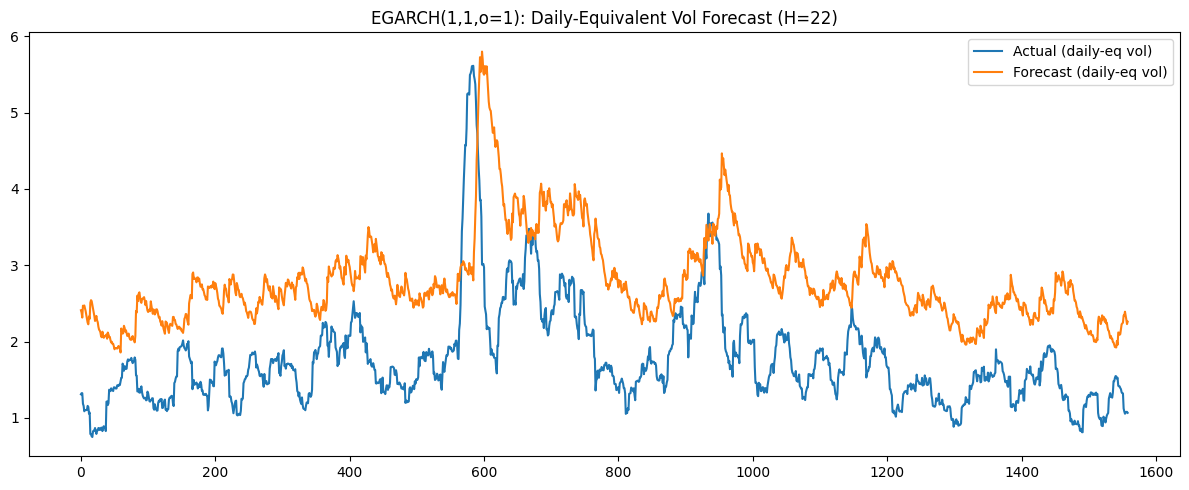

Saved EGARCH variance feature: (7791,)
Saved EGARCH volatility feature: (7791,)


In [67]:
# ======
# E-GARCH
# ======

egarch_runs = []
egarch_preds = []
egarch_feat_list = []
egarch_params_list = []  # optional

def _get_first_param(p, prefix, default=np.nan):
    keys = [k for k in p.index if k.startswith(prefix)]
    return float(p[keys[0]]) if len(keys) > 0 else float(default)

Ez = np.sqrt(2 / np.pi)  # E|Z| for standard normal

for seed in SEEDS:
    set_all_seeds(seed)

    am = arch_model(
        r_train,
        vol="EGARCH",
        p=1, o=1, q=1,         # leverage term included
        mean="Constant",
        dist="Normal",
        rescale=True
    )
    res = am.fit(disp="off")

    p = res.params
    mu    = float(p.get("mu", 0.0))
    omega = float(p["omega"])
    alpha = _get_first_param(p, "alpha[", default=0.0)
    beta  = _get_first_param(p, "beta[",  default=0.0)
    gamma = _get_first_param(p, "gamma[", default=0.0)

    egarch_params_list.append(
        {"seed": seed, "mu": mu, "omega": omega, "alpha": alpha, "beta": beta, "gamma": gamma}
    )

    feat_var_train = pd.Series(
        (res.conditional_volatility**2).values,
        index=r_train.index,
        dtype=float
    ).clip(lower=EPS)

    sigma2_prev = float(res.conditional_volatility.iloc[-1] ** 2)
    log_sigma2_prev = float(np.log(max(sigma2_prev, EPS)))

    pred_vol_series = []
    idx_series = []
    feat_var_test = []

    for tstamp, r_t in r_test.items():

        log_sigma2_k = log_sigma2_prev
        fcast_var = []

        for _ in range(H):
            log_sigma2_k = omega + beta * log_sigma2_k + alpha * Ez
            fcast_var.append(float(np.exp(log_sigma2_k)))

        pred_var_H = float(np.sum(fcast_var))
        pred_vol = float(np.sqrt(max(pred_var_H, EPS) / H))

        pred_vol_series.append(pred_vol)
        idx_series.append(tstamp)

        sigma2_curr = float(np.exp(log_sigma2_prev))
        z_t = (float(r_t) - mu) / np.sqrt(max(sigma2_curr, EPS))

        log_sigma2_prev = (
            omega
            + beta * log_sigma2_prev
            + alpha * (np.abs(z_t) - Ez)
            + gamma * z_t
        )
        feat_var_test.append(float(np.exp(log_sigma2_prev)))

    pred_vol = pd.Series(pred_vol_series, index=pd.Index(idx_series), name=f"seed_{seed}")
    egarch_preds.append(pred_vol)

    # metrics on daily-equivalent volatility
    y_true_vol = y_test.loc[pred_vol.index].values
    m = metrics_vol(y_true_vol, pred_vol.values)
    m["seed"] = seed
    egarch_runs.append(m)

    feat_var = pd.concat(
        [feat_var_train, pd.Series(feat_var_test, index=pd.Index(idx_series), dtype=float)],
        axis=0
    ).clip(lower=EPS)
    feat_var.name = f"egarch_var_seed_{seed}"
    egarch_feat_list.append(feat_var)

egarch_results = pd.DataFrame(egarch_runs)
print("EGARCH(1,1,o=1) — Daily-Equivalent Vol Results:")
display(egarch_results)

print("\nMean / Std:")
display(egarch_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

egarch_pred_mean = pd.concat(egarch_preds, axis=1).mean(axis=1)

plt.figure(figsize=(12,5))
plt.plot(y_test.loc[egarch_pred_mean.index].values, label="Actual (daily-eq vol)")
plt.plot(egarch_pred_mean.values, label="Forecast (daily-eq vol)")
plt.title(f"EGARCH(1,1,o=1): Daily-Equivalent Vol Forecast (H={H})")
plt.legend()
plt.tight_layout()
plt.show()

EGARCH_VAR_FEATURE = pd.concat(egarch_feat_list, axis=1).mean(axis=1).clip(lower=EPS)
EGARCH_VAR_FEATURE.name = "egarch_var_feature"

EGARCH_VOL_FEATURE = np.sqrt(EGARCH_VAR_FEATURE).clip(lower=EPS)
EGARCH_VOL_FEATURE.name = "egarch_vol_feature"

print("Saved EGARCH variance feature:", EGARCH_VAR_FEATURE.dropna().shape)
print("Saved EGARCH volatility feature:", EGARCH_VOL_FEATURE.dropna().shape)


EWMA (λ=0.97) — Daily-Equivalent Vol Results:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.38361,0.619362,0.413963,0.235001,0.093581,11
1,0.38361,0.619362,0.413963,0.235001,0.093581,22
2,0.38361,0.619362,0.413963,0.235001,0.093581,33
3,0.38361,0.619362,0.413963,0.235001,0.093581,44
4,0.38361,0.619362,0.413963,0.235001,0.093581,55



Mean / Std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.38361,0.619362,0.413963,2.350008e-01,0.093581
std,0.00000,0.000000,0.000000,3.103168e-17,0.000000


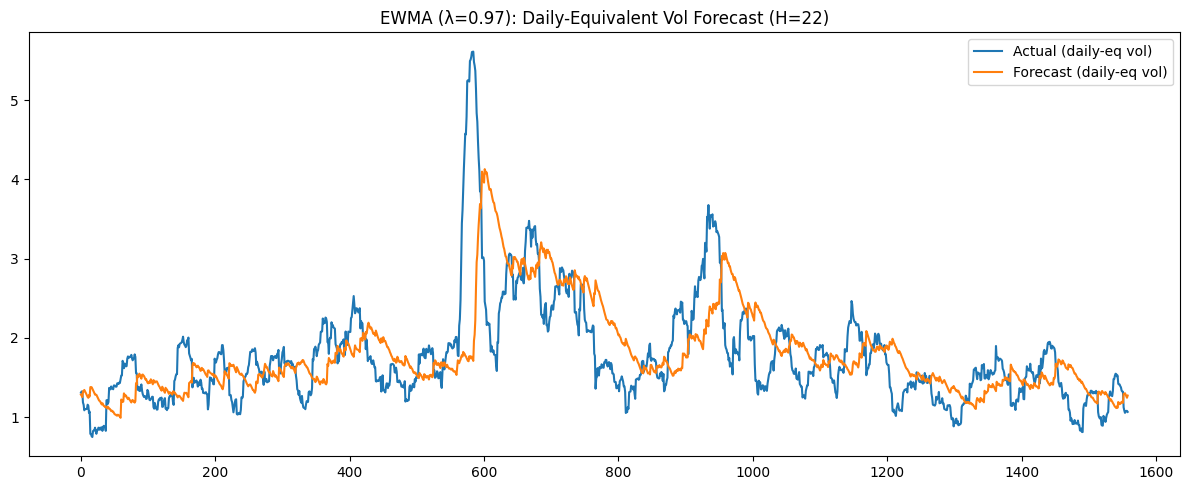

Saved EWMA variance feature: (7791,)
Saved EWMA volatility feature: (7791,)


In [68]:
# ======
# EWMA
# ======

ewma_runs = []
ewma_preds = []
ewma_feat_list = []

LAMBDA = 0.97

for seed in SEEDS:
    set_all_seeds(seed)

    sigma2_prev = float(r_train.iloc[-1] ** 2)
    sigma2_prev = max(sigma2_prev, EPS)

    pred_vol_series = []
    idx_series = []
    feat_var_test = []


    sigma2_train = []
    for r in r_train.values:
        sigma2_prev = LAMBDA * sigma2_prev + (1 - LAMBDA) * float(r**2)
        sigma2_prev = max(sigma2_prev, EPS)
        sigma2_train.append(sigma2_prev)
    feat_var_train = pd.Series(sigma2_train, index=r_train.index, dtype=float)

    sigma2_prev = float(feat_var_train.iloc[-1])

    for tstamp, r_t in r_test.items():
        pred_var_H = float(H * sigma2_prev)

        pred_vol = float(np.sqrt(max(pred_var_H, EPS) / H))
        pred_vol_series.append(pred_vol)
        idx_series.append(tstamp)

        sigma2_prev = LAMBDA * sigma2_prev + (1 - LAMBDA) * float(r_t**2)
        sigma2_prev = max(sigma2_prev, EPS)
        feat_var_test.append(sigma2_prev)

    pred_vol = pd.Series(pred_vol_series, index=pd.Index(idx_series), name=f"seed_{seed}")
    ewma_preds.append(pred_vol)

    y_true_vol = y_test.loc[pred_vol.index].values # metrics on daily equivalent volatily
    m = metrics_vol(y_true_vol, pred_vol.values)
    m["seed"] = seed
    ewma_runs.append(m)

    feat_var = pd.concat(
        [feat_var_train, pd.Series(feat_var_test, index=pd.Index(idx_series), dtype=float)],
        axis=0
    ).clip(lower=EPS)
    feat_var.name = f"ewma_var_seed_{seed}"
    ewma_feat_list.append(feat_var)

ewma_results = pd.DataFrame(ewma_runs)
print(f"EWMA (λ={LAMBDA}) — Daily-Equivalent Vol Results:")
display(ewma_results)

print("\nMean / Std:")
display(ewma_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

ewma_pred_mean = pd.concat(ewma_preds, axis=1).mean(axis=1)

plt.figure(figsize=(12,5))
plt.plot(y_test.loc[ewma_pred_mean.index].values, label="Actual (daily-eq vol)")
plt.plot(ewma_pred_mean.values, label="Forecast (daily-eq vol)")
plt.title(f"EWMA (λ={LAMBDA}): Daily-Equivalent Vol Forecast (H={H})")
plt.legend()
plt.tight_layout()
plt.show()

EWMA_VAR_FEATURE = pd.concat(ewma_feat_list, axis=1).mean(axis=1).clip(lower=EPS)
EWMA_VAR_FEATURE.name = "ewma_var_feature"

EWMA_VOL_FEATURE = np.sqrt(EWMA_VAR_FEATURE).clip(lower=EPS)
EWMA_VOL_FEATURE.name = "ewma_vol_feature"

print("Saved EWMA variance feature:", EWMA_VAR_FEATURE.dropna().shape)
print("Saved EWMA volatility feature:", EWMA_VOL_FEATURE.dropna().shape)


#UNIVARIATE Neural Networks

In [140]:
# building feartures

EPS = 1e-12

df = pd.read_csv(r'wheat_rolling_futures.csv')

# defining exogenous inputs
df["ret"] = 100 * np.log(df["PX_LAST"]).diff()
df["abs_ret"] = df["ret"].abs()
df["ret2"] = df["ret"] ** 2
df["log_ret2"] = np.log(df["ret2"] + EPS)

df["gold_ret"] = 100 * np.log(df["PX_GOLD"]).diff()

df["prod_growth"] = np.log(df["WUSETWPR"]).diff()

feat_cols = ["ret", "abs_ret", "ret2", "log_ret2", "gold_ret", "prod_growth"]

df_feat = df[feat_cols].dropna()

print(df_feat.head())


        ret   abs_ret      ret2  log_ret2  gold_ret  prod_growth
1 -2.363160  2.363160  5.584527  1.720000  0.163883          0.0
2  1.777585  1.777585  3.159809  1.150512 -0.163883          0.0
3 -0.320856  0.320856  0.102949 -2.273526  0.879292          0.0
4 -1.293819  1.293819  1.673967  0.515196 -0.200301          0.0
5  1.881270  1.881270  3.539178  1.263894 -0.678992          0.0


In [141]:
def make_seq_dataset_multivariate(
    X_df: pd.DataFrame,
    y_var: pd.Series,
    lookback: int
):
    """
    X_df: feature dataframe indexed by date
    y_var: realized H-day variance (aligned)
    """
    data = X_df.join(y_var.rename("y_var")).dropna()

    X = data[X_df.columns].values.astype(np.float32)
    y = data["y_var"].values.astype(np.float32)
    idx = data.index

    X_list, y_list, idx_list = [], [], []

    for i in range(lookback - 1, len(data)):
        X_list.append(X[i - lookback + 1 : i + 1, :])
        y_list.append(np.log(y[i] + EPS))   # log variance target
        idx_list.append(idx[i])

    X_seq = np.stack(X_list, axis=0)
    y_log = np.array(y_list)
    idx_out = pd.Index(idx_list)

    return X_seq, y_log, idx_out

Xtr_seq, ytr_log, idx_tr = make_seq_dataset_multivariate(
    df_feat.loc[r_train.index], y_train, LOOKBACK
)

Xte_seq, yte_log, idx_te = make_seq_dataset_multivariate(
    df_feat.loc[r_test.index], y_test, LOOKBACK
)

mu = Xtr_seq.mean(axis=(0,1), keepdims=True)
sd = Xtr_seq.std(axis=(0,1), keepdims=True) + 1e-8

Xtr_seq_s = (Xtr_seq - mu) / sd
Xte_seq_s = (Xte_seq - mu) / sd

print(Xtr_seq_s.shape, Xte_seq_s.shape)



(6173, 60, 6) (1500, 60, 6)


In [74]:
def exp_back_to_var(y_log):
    return np.exp(np.asarray(y_log, dtype=float))

def eval_nn_logvar(y_true_log, y_pred_log):
    y_true_var = exp_back_to_var(y_true_log)
    y_pred_var = np.maximum(exp_back_to_var(y_pred_log), EPS)
    return metrics_vol(y_true_var, y_pred_var), y_true_var, y_pred_var


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.349487,0.591174,0.414525,0.224541,0.079443,11
1,0.351710,0.593051,0.392923,0.204945,0.064875,22
2,0.327507,0.572282,0.397690,0.219019,0.077225,33
3,0.362149,0.601788,0.410478,0.214333,0.071365,44
4,0.370279,0.608505,0.402406,0.210974,0.069809,55


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.352226,0.593360,0.403604,0.214762,0.072543
std,0.016149,0.013689,0.008903,0.007494,0.005856


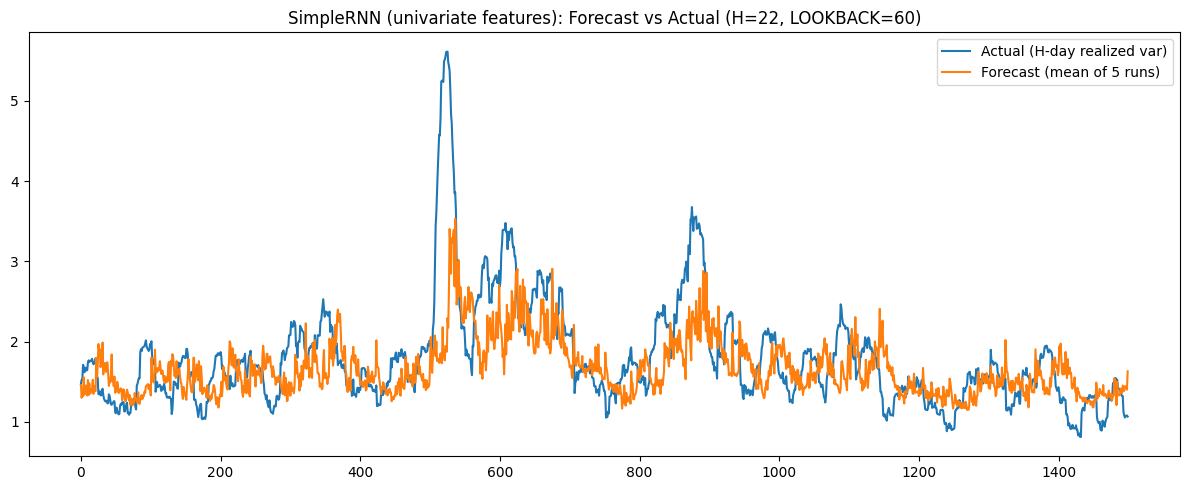

In [78]:
# ===
# RNN
# ===
def build_simple_rnn(lookback: int, n_features: int):
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.SimpleRNN(64, activation="tanh")(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)  # log-variance
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

rnn_runs, rnn_preds_log = [], []
n_features = Xtr_seq_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_simple_rnn(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(
        Xtr_seq_s, ytr_log,
        validation_split=0.2,
        epochs=300,
        batch_size=256,
        verbose=0,
        callbacks=cb
    )

    pred_log = model.predict(Xte_seq_s, verbose=0).reshape(-1)
    m, y_true_var, y_pred_var = eval_nn_logvar(yte_log, pred_log)
    m["seed"] = seed
    rnn_runs.append(m)

    rnn_preds_log.append(pd.Series(pred_log, index=idx_te, name=f"seed_{seed}"))

rnn_results = pd.DataFrame(rnn_runs)
display(rnn_results)
display(rnn_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

rnn_pred_log_mat = pd.concat(rnn_preds_log, axis=1)
rnn_pred_var_mean = np.exp(rnn_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_log, index=idx_te)).values, label="Actual (H-day realized var)")
plt.plot(rnn_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"SimpleRNN (univariate features): Forecast vs Actual (H={H}, LOOKBACK={LOOKBACK})")
plt.legend()
plt.tight_layout()
plt.show()


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.314554,0.560851,0.368913,0.196494,0.060497,11
1,0.339016,0.582251,0.380474,0.197872,0.059735,22
2,0.322769,0.568128,0.368822,0.193576,0.059104,33
3,0.319038,0.564835,0.363878,0.190744,0.057824,44
4,0.306272,0.553419,0.374125,0.205116,0.066480,55


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.320330,0.565897,0.371243,0.196760,0.060728
std,0.012122,0.010662,0.006306,0.005419,0.003361


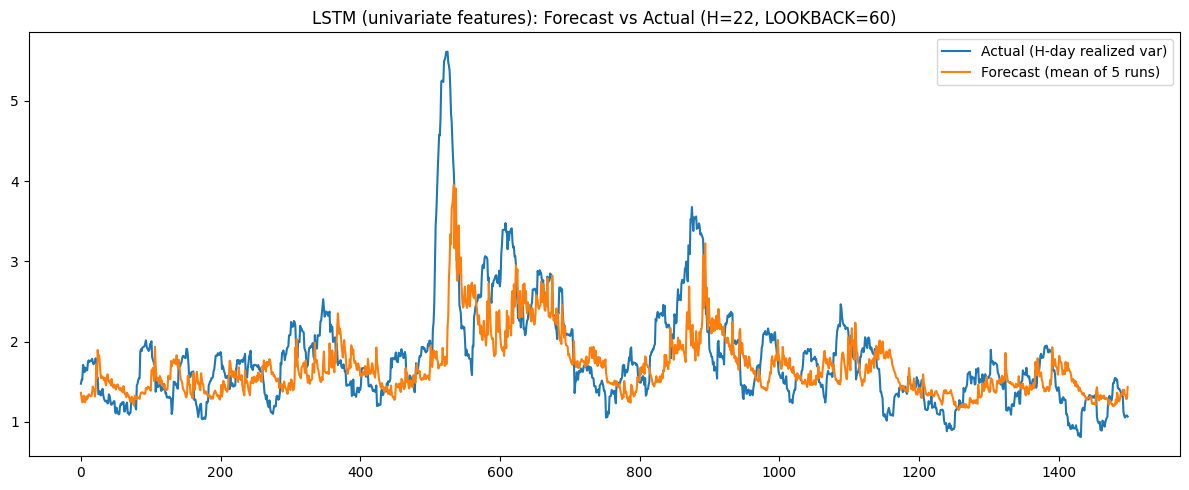

In [79]:
# ====
# LSTM
# ====
def build_lstm(lookback: int, n_features: int):
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.LSTM(64)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)  # log-variance
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

lstm_runs, lstm_preds_log = [], []
n_features = Xtr_seq_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(
        Xtr_seq_s, ytr_log,
        validation_split=0.2,
        epochs=300,
        batch_size=256,
        verbose=0,
        callbacks=cb
    )

    pred_log = model.predict(Xte_seq_s, verbose=0).reshape(-1)
    m, y_true_var, y_pred_var = eval_nn_logvar(yte_log, pred_log)
    m["seed"] = seed
    lstm_runs.append(m)

    lstm_preds_log.append(pd.Series(pred_log, index=idx_te, name=f"seed_{seed}"))

lstm_results = pd.DataFrame(lstm_runs)
display(lstm_results)
display(lstm_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

lstm_pred_log_mat = pd.concat(lstm_preds_log, axis=1)
lstm_pred_var_mean = np.exp(lstm_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_log, index=idx_te)).values, label="Actual (H-day realized var)")
plt.plot(lstm_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"LSTM (univariate features): Forecast vs Actual (H={H}, LOOKBACK={LOOKBACK})")
plt.legend()
plt.tight_layout()
plt.show()


In [80]:
summary = []

def add_summary(name, df_runs):
    agg = df_runs[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"])
    out = pd.concat(
        [agg.loc["mean"].rename("mean"), agg.loc["std"].rename("std")],
        axis=1
    ).T
    out.insert(0, "model", name)
    return out

summary.append(add_summary("GARCH(1,1)", garch_results))
summary.append(add_summary("MLP", mlp_results))
summary.append(add_summary("SimpleRNN", rnn_results))
summary.append(add_summary("LSTM", lstm_results))

summary_df = pd.concat(summary, axis=0).reset_index(drop=True)
display(summary_df)


,model,MSE,RMSE,MAE,HMAE,HMSE
0,"GARCH(1,1)",0.350076,0.591672,0.394645,0.228325,0.090079
1,"GARCH(1,1)",0.000000,0.000000,0.000000,0.000000,0.000000
2,MLP,0.384029,0.619625,0.395769,0.200833,0.063456
3,MLP,0.013371,0.010827,0.005147,0.001626,0.001111
4,SimpleRNN,0.352226,0.593360,0.403604,0.214762,0.072543
5,SimpleRNN,0.016149,0.013689,0.008903,0.007494,0.005856
6,LSTM,0.320330,0.565897,0.371243,0.196760,0.060728
7,LSTM,0.012122,0.010662,0.006306,0.005419,0.003361


After appropriate feature transformation and target stabilization, recurrent neural networks—particularly LSTM—achieve performance comparable to GARCH(1,1) and outperform RNNs in terms of MSE. LSTM models exhibit lower error variance and improved stability across runs.

# Hybrid Models

In [84]:
# building dataset and feastures

def make_seq_dataset_hybrid_rnn(
    returns_series: pd.Series,
    y_var_series: pd.Series,
    feat_var_series: pd.Series,
    lookback: int
):
    r = returns_series.astype(float)
    yv = y_var_series.astype(float)
    fv = feat_var_series.reindex(r.index).astype(float)

    feats = pd.DataFrame({
        "r": r,
        "abs_r": np.abs(r),
        "r2": r**2,
        "log_r2": np.log(r**2 + EPS),
        "feat_var": fv
    }).dropna()

    yv = yv.reindex(feats.index)
    data = feats.join(yv.rename("y_var")).dropna()

    X = data[["r","abs_r","r2","log_r2","feat_var"]].values.astype(np.float32)
    y = data["y_var"].values.astype(np.float32)
    idx = data.index

    X_list, y_list, idx_list = [], [], []
    for i in range(lookback - 1, len(data)):
        X_list.append(X[i - lookback + 1 : i + 1, :])  # (lookback, 5)
        y_list.append(np.log(float(y[i]) + EPS))
        idx_list.append(idx[i])

    X_seq = np.stack(X_list, axis=0)              # (N, lookback, 5)
    y_log = np.array(y_list, dtype=np.float32)    # (N,)
    idx_out = pd.Index(idx_list)

    return X_seq, y_log, idx_out


# RNN + 1 econometric model (GARCH/E-GARCH/EWMA)




In [85]:
def build_hybrid_rnn(lookback: int, n_features: int):
    """
    SimpleRNN used for hybrid models.
    Input shape: (lookback, n_features)
    Output: log-variance
    """
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.SimpleRNN(64, activation="tanh")(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)   # log-variance
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse"
    )
    return model


Hybrid SimpleRNN + GARCH feature (per run):


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.328339,0.573009,0.381676,0.205133,0.066410,11
1,0.332835,0.576918,0.369936,0.192300,0.057909,22
2,0.336807,0.580351,0.373087,0.194962,0.061367,33
3,0.339025,0.582258,0.381507,0.199760,0.062571,44
4,0.333074,0.577126,0.377115,0.198461,0.062542,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.334016,0.577932,0.376664,0.198123,0.062159
std,0.004104,0.003553,0.005168,0.004895,0.003045


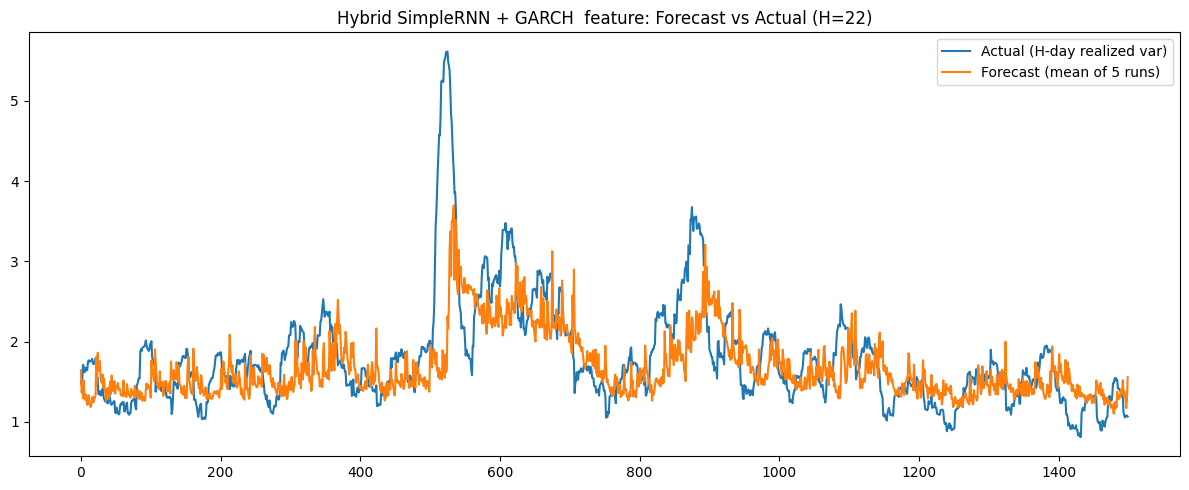

In [89]:
# ==================
# Hybrid RNN: GARCH
# ==================

Xtr_h, ytr_h_log, idx_tr_h = make_seq_dataset_hybrid_rnn(
    r_train, y_train, GARCH_VAR_FEATURE.loc[r_train.index], LOOKBACK
)
Xte_h, yte_h_log, idx_te_h = make_seq_dataset_hybrid_rnn(
    r_test,  y_test,  GARCH_VAR_FEATURE.loc[r_test.index],  LOOKBACK
)

mu_h = Xtr_h.mean(axis=(0,1), keepdims=True)
sd_h = Xtr_h.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_h_s = (Xtr_h - mu_h) / sd_h
Xte_h_s = (Xte_h - mu_h) / sd_h

hyb_rnn_garch_runs, hyb_rnn_garch_preds_log = [], []
n_features = Xtr_h_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_hybrid_rnn(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_h_s, ytr_h_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_h_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_h_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    hyb_rnn_garch_runs.append(m)
    hyb_rnn_garch_preds_log.append(pd.Series(pred_log, index=idx_te_h, name=f"seed_{seed}"))

hyb_rnn_garch_results = pd.DataFrame(hyb_rnn_garch_runs)
print("Hybrid SimpleRNN + GARCH feature (per run):")
display(hyb_rnn_garch_results)
print("\nMean/std:")
display(hyb_rnn_garch_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

hyb_rnn_garch_pred_log_mat = pd.concat(hyb_rnn_garch_preds_log, axis=1)
hyb_rnn_garch_pred_var_mean = np.exp(hyb_rnn_garch_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_h_log, index=idx_te_h)).values, label="Actual (H-day realized var)")
plt.plot(hyb_rnn_garch_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Hybrid SimpleRNN + GARCH  feature: Forecast vs Actual (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


Hybrid SimpleRNN + EGARCH feature (per run):


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.329828,0.574306,0.384518,0.206755,0.067807,11
1,0.334027,0.577951,0.372404,0.193312,0.058334,22
2,0.336301,0.579915,0.380733,0.203280,0.067916,33
3,0.340805,0.583785,0.379206,0.197401,0.060988,44
4,0.336495,0.580082,0.381027,0.199313,0.061937,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.335491,0.579208,0.379578,0.200012,0.063396
std,0.004004,0.003457,0.004456,0.005204,0.004285


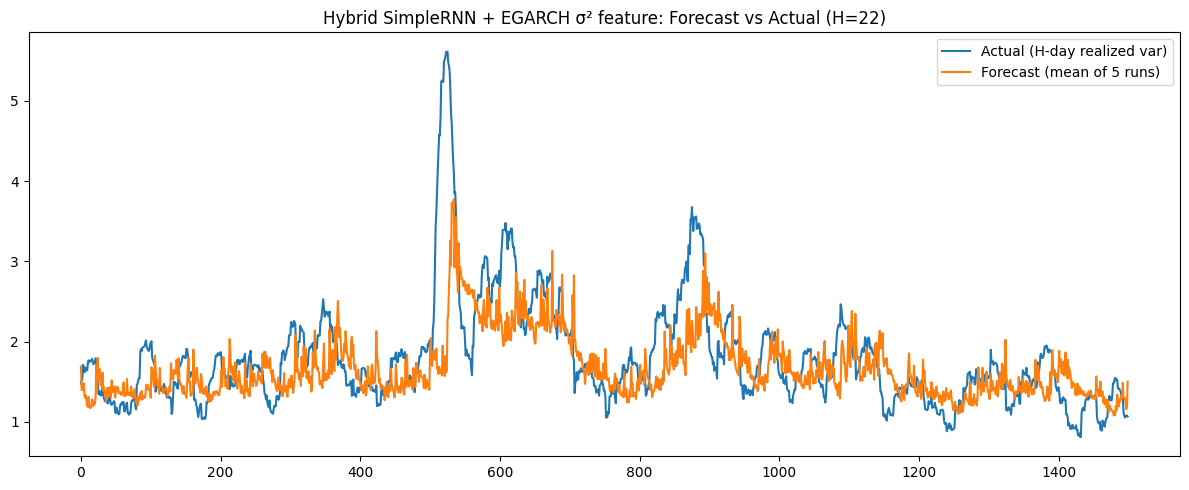

In [90]:
# ==================
# Hybrid RNN: E-GARCH
# ==================

Xtr_h, ytr_h_log, idx_tr_h = make_seq_dataset_hybrid_rnn(
    r_train, y_train, EGARCH_VAR_FEATURE.loc[r_train.index], LOOKBACK
)
Xte_h, yte_h_log, idx_te_h = make_seq_dataset_hybrid_rnn(
    r_test,  y_test,  EGARCH_VAR_FEATURE.loc[r_test.index],  LOOKBACK
)

mu_h = Xtr_h.mean(axis=(0,1), keepdims=True)
sd_h = Xtr_h.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_h_s = (Xtr_h - mu_h) / sd_h
Xte_h_s = (Xte_h - mu_h) / sd_h

hyb_rnn_egarch_runs, hyb_rnn_egarch_preds_log = [], []
n_features = Xtr_h_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_hybrid_rnn(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_h_s, ytr_h_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_h_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_h_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    hyb_rnn_egarch_runs.append(m)
    hyb_rnn_egarch_preds_log.append(pd.Series(pred_log, index=idx_te_h, name=f"seed_{seed}"))

hyb_rnn_egarch_results = pd.DataFrame(hyb_rnn_egarch_runs)
print("Hybrid SimpleRNN + EGARCH feature (per run):")
display(hyb_rnn_egarch_results)
print("\nMean/std:")
display(hyb_rnn_egarch_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

hyb_rnn_egarch_pred_log_mat = pd.concat(hyb_rnn_egarch_preds_log, axis=1)
hyb_rnn_egarch_pred_var_mean = np.exp(hyb_rnn_egarch_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_h_log, index=idx_te_h)).values, label="Actual (H-day realized var)")
plt.plot(hyb_rnn_egarch_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Hybrid SimpleRNN + EGARCH σ² feature: Forecast vs Actual (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


# EWMA + RNN

Hybrid SimpleRNN + EWMA feature (per run):


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.333028,0.577086,0.382641,0.205212,0.066280,11
1,0.328540,0.573184,0.370445,0.194414,0.059290,22
2,0.344151,0.586643,0.380518,0.198454,0.062416,33
3,0.341748,0.584592,0.378901,0.197586,0.061412,44
4,0.331468,0.575733,0.376153,0.198946,0.062057,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.335787,0.579448,0.377732,0.198922,0.062291
std,0.006787,0.005849,0.004712,0.003933,0.002538


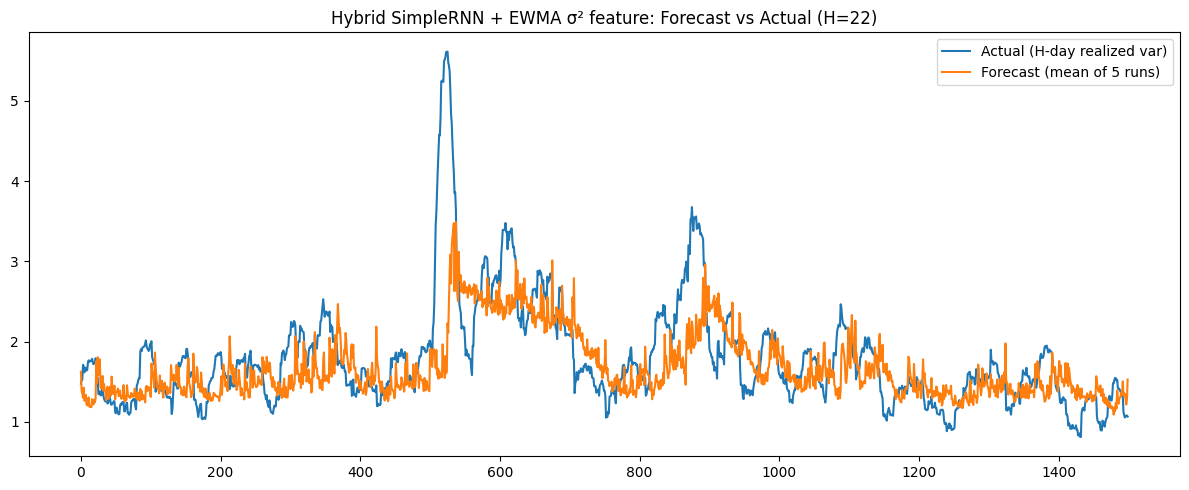

In [91]:
# ==================
# Hybrid RNN: EWMA
# ==================

Xtr_h, ytr_h_log, idx_tr_h = make_seq_dataset_hybrid_rnn(
    r_train, y_train, EWMA_VAR_FEATURE.loc[r_train.index], LOOKBACK
)
Xte_h, yte_h_log, idx_te_h = make_seq_dataset_hybrid_rnn(
    r_test,  y_test,  EWMA_VAR_FEATURE.loc[r_test.index],  LOOKBACK
)

mu_h = Xtr_h.mean(axis=(0,1), keepdims=True)
sd_h = Xtr_h.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_h_s = (Xtr_h - mu_h) / sd_h
Xte_h_s = (Xte_h - mu_h) / sd_h

hyb_rnn_ewma_runs, hyb_rnn_ewma_preds_log = [], []
n_features = Xtr_h_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_hybrid_rnn(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_h_s, ytr_h_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_h_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_h_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    hyb_rnn_ewma_runs.append(m)
    hyb_rnn_ewma_preds_log.append(pd.Series(pred_log, index=idx_te_h, name=f"seed_{seed}"))

hyb_rnn_ewma_results = pd.DataFrame(hyb_rnn_ewma_runs)
print("Hybrid SimpleRNN + EWMA feature (per run):")
display(hyb_rnn_ewma_results)
print("\nMean/std:")
display(hyb_rnn_ewma_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

hyb_rnn_ewma_pred_log_mat = pd.concat(hyb_rnn_ewma_preds_log, axis=1)
hyb_rnn_ewma_pred_var_mean = np.exp(hyb_rnn_ewma_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_h_log, index=idx_te_h)).values, label="Actual (H-day realized var)")
plt.plot(hyb_rnn_ewma_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Hybrid SimpleRNN + EWMA σ² feature: Forecast vs Actual (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


# LSTM + 1 econometric model (GARCH/E-GARCH/EWMA)




In [95]:
def build_hybrid_lstm(lookback: int, n_features: int):
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.LSTM(64)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)  # log-variance
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

Hybrid LSTM + GARCH σ² feature (per run):


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.322154,0.567586,0.372454,0.199140,0.063071,11
1,0.324803,0.569915,0.374425,0.197906,0.061044,22
2,0.315968,0.562110,0.364664,0.195083,0.060081,33
3,0.326466,0.571372,0.367715,0.192028,0.056970,44
4,0.300756,0.548412,0.355775,0.191354,0.057641,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.318029,0.563879,0.367007,0.195102,0.059761
std,0.010449,0.009336,0.007363,0.003452,0.002499


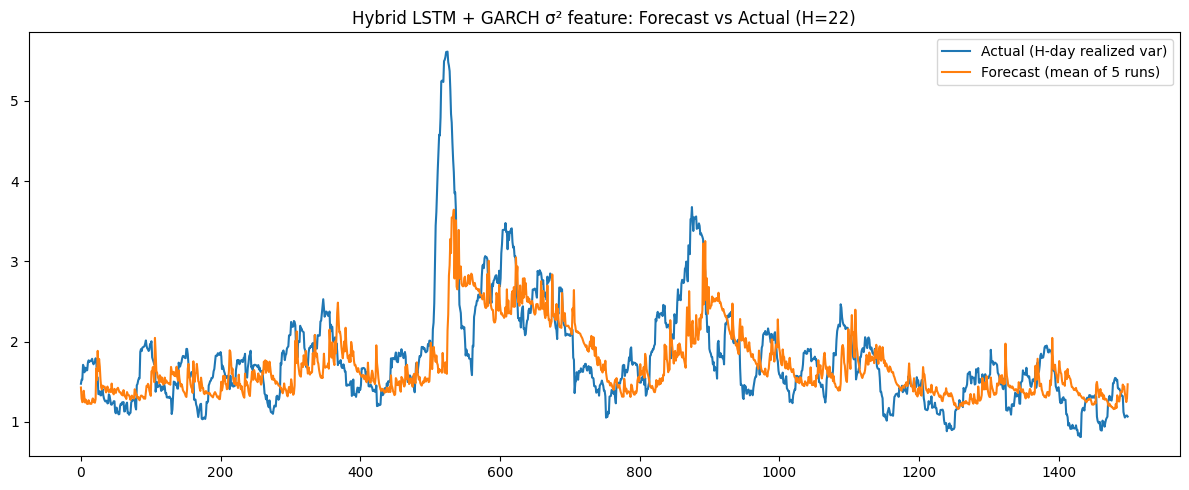

In [96]:
# ==================
# Hybrid LSTM: GARCH
# ==================

Xtr_h, ytr_h_log, idx_tr_h = make_seq_dataset_hybrid_rnn(
    r_train, y_train, GARCH_VAR_FEATURE.loc[r_train.index], LOOKBACK
)
Xte_h, yte_h_log, idx_te_h = make_seq_dataset_hybrid_rnn(
    r_test,  y_test,  GARCH_VAR_FEATURE.loc[r_test.index],  LOOKBACK
)

mu_h = Xtr_h.mean(axis=(0,1), keepdims=True)
sd_h = Xtr_h.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_h_s = (Xtr_h - mu_h) / sd_h
Xte_h_s = (Xte_h - mu_h) / sd_h

hyb_lstm_garch_runs, hyb_lstm_garch_preds_log = [], []

n_features = Xtr_h_s.shape[-1]
for seed in SEEDS:
    set_all_seeds(seed)

    model = build_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_h_s, ytr_h_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_h_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_h_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    hyb_lstm_garch_runs.append(m)
    hyb_lstm_garch_preds_log.append(pd.Series(pred_log, index=idx_te_h, name=f"seed_{seed}"))

hyb_lstm_garch_results = pd.DataFrame(hyb_lstm_garch_runs)
print("Hybrid LSTM + GARCH σ² feature (per run):")
display(hyb_lstm_garch_results)
print("\nMean/std:")
display(hyb_lstm_garch_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

hyb_lstm_garch_pred_log_mat = pd.concat(hyb_lstm_garch_preds_log, axis=1)
hyb_lstm_garch_pred_var_mean = np.exp(hyb_lstm_garch_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_h_log, index=idx_te_h)).values, label="Actual (H-day realized var)")
plt.plot(hyb_lstm_garch_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Hybrid LSTM + GARCH σ² feature: Forecast vs Actual (H={H})")
plt.legend()
plt.tight_layout()
plt.show()

Hybrid LSTM + EGARCH σ² feature (per run):


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.321236,0.566777,0.374490,0.202671,0.066735,11
1,0.316091,0.562220,0.366127,0.193833,0.059365,22
2,0.315234,0.561457,0.363783,0.193692,0.059534,33
3,0.327142,0.571963,0.366944,0.191628,0.057241,44
4,0.302903,0.550366,0.359111,0.192841,0.058665,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.316521,0.562557,0.366091,0.194933,0.060308
std,0.008977,0.008004,0.005597,0.004414,0.003705


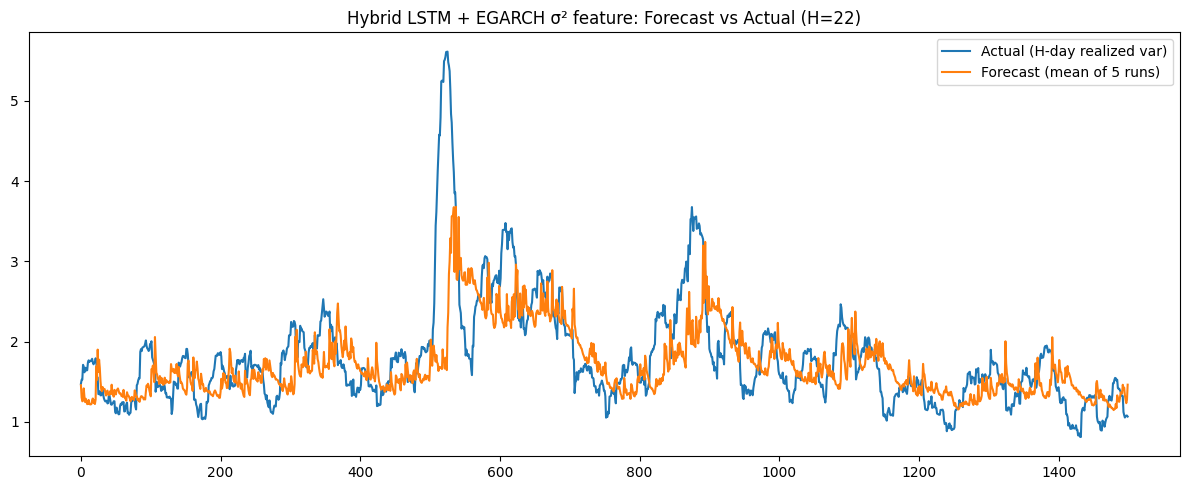

In [97]:
# ==================
# Hybrid LSTM: E-GARCH
# ==================

Xtr_h, ytr_h_log, idx_tr_h = make_seq_dataset_hybrid_rnn(
    r_train, y_train, EGARCH_VAR_FEATURE.loc[r_train.index], LOOKBACK
)
Xte_h, yte_h_log, idx_te_h = make_seq_dataset_hybrid_rnn(
    r_test,  y_test,  EGARCH_VAR_FEATURE.loc[r_test.index],  LOOKBACK
)

mu_h = Xtr_h.mean(axis=(0,1), keepdims=True)
sd_h = Xtr_h.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_h_s = (Xtr_h - mu_h) / sd_h
Xte_h_s = (Xte_h - mu_h) / sd_h

hyb_lstm_egarch_runs, hyb_lstm_egarch_preds_log = [], []

n_features = Xtr_h_s.shape[-1]
for seed in SEEDS:
    set_all_seeds(seed)

    model = build_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_h_s, ytr_h_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_h_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_h_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    hyb_lstm_egarch_runs.append(m)
    hyb_lstm_egarch_preds_log.append(pd.Series(pred_log, index=idx_te_h, name=f"seed_{seed}"))

hyb_lstm_egarch_results = pd.DataFrame(hyb_lstm_egarch_runs)
print("Hybrid LSTM + EGARCH σ² feature (per run):")
display(hyb_lstm_egarch_results)
print("\nMean/std:")
display(hyb_lstm_egarch_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

hyb_lstm_egarch_pred_log_mat = pd.concat(hyb_lstm_egarch_preds_log, axis=1)
hyb_lstm_egarch_pred_var_mean = np.exp(hyb_lstm_egarch_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_h_log, index=idx_te_h)).values, label="Actual (H-day realized var)")
plt.plot(hyb_lstm_egarch_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Hybrid LSTM + EGARCH σ² feature: Forecast vs Actual (H={H})")
plt.legend()
plt.tight_layout()
plt.show()

Hybrid LSTM + EWMA σ² feature (per run):


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.328963,0.573553,0.378003,0.203448,0.066247,11
1,0.338803,0.582068,0.386974,0.203220,0.063399,22
2,0.317924,0.563848,0.368418,0.197801,0.061399,33
3,0.350149,0.591734,0.378623,0.196811,0.062042,44
4,0.304249,0.551588,0.358971,0.193299,0.058239,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.328018,0.572558,0.374198,0.198916,0.062265
std,0.017845,0.015611,0.010754,0.004367,0.002922


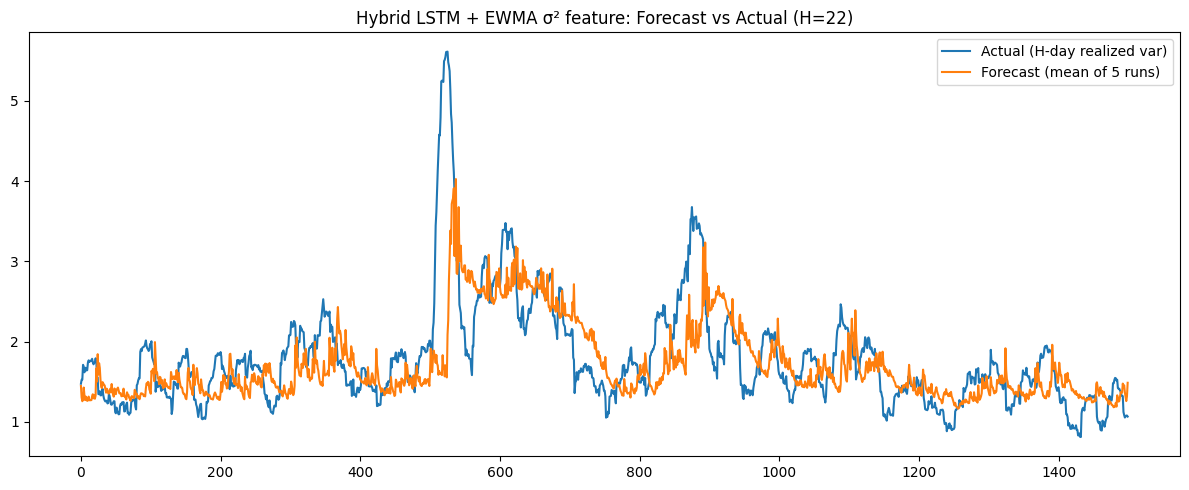

In [98]:
# ==================
# Hybrid LSTM: EWMA
# ==================

Xtr_h, ytr_h_log, idx_tr_h = make_seq_dataset_hybrid_rnn(
    r_train, y_train, EWMA_VAR_FEATURE.loc[r_train.index], LOOKBACK
)
Xte_h, yte_h_log, idx_te_h = make_seq_dataset_hybrid_rnn(
    r_test,  y_test,  EWMA_VAR_FEATURE.loc[r_test.index],  LOOKBACK
)

mu_h = Xtr_h.mean(axis=(0,1), keepdims=True)
sd_h = Xtr_h.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_h_s = (Xtr_h - mu_h) / sd_h
Xte_h_s = (Xte_h - mu_h) / sd_h

hyb_lstm_ewma_runs, hyb_lstm_ewma_preds_log = [], []

n_features = Xtr_h_s.shape[-1]
for seed in SEEDS:
    set_all_seeds(seed)

    model = build_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_h_s, ytr_h_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_h_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_h_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    hyb_lstm_ewma_runs.append(m)
    hyb_lstm_ewma_preds_log.append(pd.Series(pred_log, index=idx_te_h, name=f"seed_{seed}"))

hyb_lstm_ewma_results = pd.DataFrame(hyb_lstm_ewma_runs)
print("Hybrid LSTM + EWMA σ² feature (per run):")
display(hyb_lstm_ewma_results)
print("\nMean/std:")
display(hyb_lstm_ewma_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

hyb_lstm_ewma_pred_log_mat = pd.concat(hyb_lstm_ewma_preds_log, axis=1)
hyb_lstm_ewma_pred_var_mean = np.exp(hyb_lstm_ewma_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_h_log, index=idx_te_h)).values, label="Actual (H-day realized var)")
plt.plot(hyb_lstm_ewma_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Hybrid LSTM + EWMA σ² feature: Forecast vs Actual (H={H})")
plt.legend()
plt.tight_layout()
plt.show()

# LSTM + 2 econometric model (GARCH/E-GARCH/EWMA)

we use combination of 2 of 3 differnet models and try with LSTM. We use LSTMs instead of RNNs as we can observe that LSTMs perform better on average as compared to RNNs which has as higher RMSE




In [102]:
def make_seq_dataset_double_hybrid(
    returns_series: pd.Series,
    y_var_series: pd.Series,
    feat_var_1: pd.Series,
    feat_var_2: pd.Series,
    lookback: int
):
    r = returns_series.astype(float)
    yv = y_var_series.astype(float)

    f1 = feat_var_1.reindex(r.index).astype(float)
    f2 = feat_var_2.reindex(r.index).astype(float)

    feats = pd.DataFrame({
        "r": r,
        "abs_r": np.abs(r),
        "r2": r**2,
        "log_r2": np.log(r**2 + EPS),
        "feat1": f1,
        "feat2": f2,
    }).dropna()

    yv = yv.reindex(feats.index)
    data = feats.join(yv.rename("y_var")).dropna()

    X = data[["r","abs_r","r2","log_r2","feat1","feat2"]].values.astype(np.float32)
    y = data["y_var"].values.astype(np.float32)
    idx = data.index

    X_list, y_list, idx_list = [], [], []
    for i in range(lookback - 1, len(data)):
        X_list.append(X[i - lookback + 1 : i + 1, :])  # (lookback, 6)
        y_list.append(np.log(float(y[i]) + EPS))
        idx_list.append(idx[i])

    X_seq = np.stack(X_list, axis=0)
    y_log = np.array(y_list, dtype=np.float32)
    idx_out = pd.Index(idx_list)
    return X_seq, y_log, idx_out


In [103]:
def build_double_hybrid_lstm(lookback: int, n_features: int):
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.LSTM(64)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)  # log-variance
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


Double-hybrid LSTM (GARCH + EGARCH) per run:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.312878,0.559355,0.366293,0.197073,0.062185,11
1,0.305771,0.552966,0.358168,0.192730,0.059556,22
2,0.317504,0.563475,0.363027,0.192423,0.058814,33
3,0.318789,0.564614,0.363114,0.190779,0.056733,44
4,0.304454,0.551773,0.358597,0.191642,0.057353,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.311879,0.558437,0.361840,0.192929,0.058928
std,0.006573,0.005889,0.003423,0.002437,0.002140


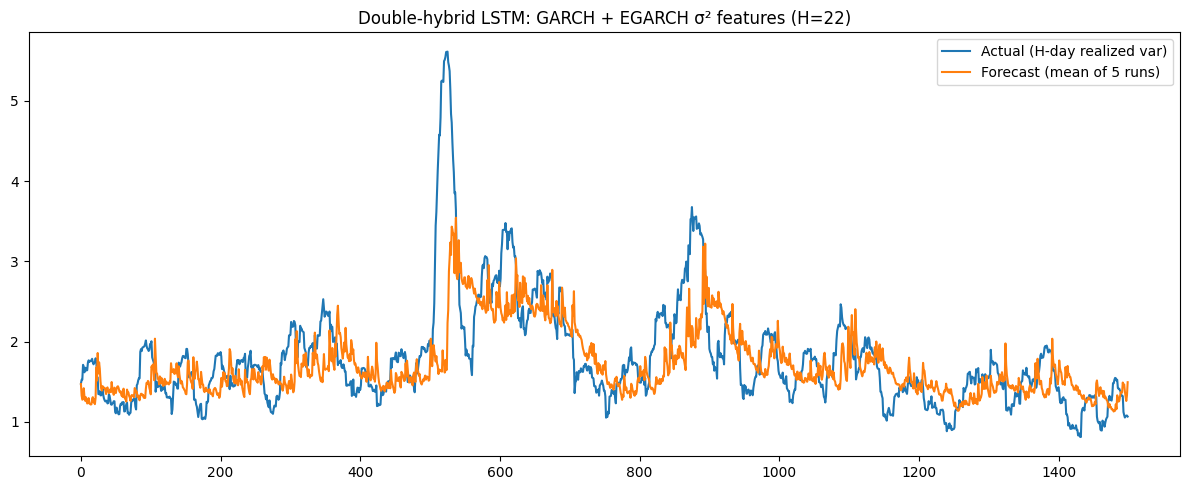

In [104]:
# ============================
# Double-hybrid LSTM: GARCH + EGARCH
# ============================

Xtr, ytr_log, idx_tr = make_seq_dataset_double_hybrid(
    r_train, y_train,
    GARCH_VAR_FEATURE.loc[r_train.index],
    EGARCH_VAR_FEATURE.loc[r_train.index],
    LOOKBACK
)
Xte, yte_log, idx_te = make_seq_dataset_double_hybrid(
    r_test, y_test,
    GARCH_VAR_FEATURE.loc[r_test.index],
    EGARCH_VAR_FEATURE.loc[r_test.index],
    LOOKBACK
)

mu = Xtr.mean(axis=(0,1), keepdims=True)
sd = Xtr.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_s = (Xtr - mu) / sd
Xte_s = (Xte - mu) / sd

dh_lstm_ge_runs, dh_lstm_ge_preds_log = [], []
n_features = Xtr_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_double_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_s, ytr_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    dh_lstm_ge_runs.append(m)
    dh_lstm_ge_preds_log.append(pd.Series(pred_log, index=idx_te, name=f"seed_{seed}"))

dh_lstm_ge_results = pd.DataFrame(dh_lstm_ge_runs)
print("Double-hybrid LSTM (GARCH + EGARCH) per run:")
display(dh_lstm_ge_results)
print("\nMean/std:")
display(dh_lstm_ge_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

dh_lstm_ge_pred_log_mat = pd.concat(dh_lstm_ge_preds_log, axis=1)
dh_lstm_ge_pred_var_mean = np.exp(dh_lstm_ge_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_log, index=idx_te)).values, label="Actual (H-day realized var)")
plt.plot(dh_lstm_ge_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Double-hybrid LSTM: GARCH + EGARCH σ² features (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


Double-hybrid LSTM (GARCH + EWMA) per run:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.315794,0.561955,0.370384,0.200629,0.063730,11
1,0.318454,0.564317,0.367183,0.196272,0.060899,22
2,0.317149,0.563159,0.369709,0.196969,0.060021,33
3,0.323798,0.569032,0.365032,0.191145,0.056412,44
4,0.308465,0.555396,0.364464,0.196106,0.059556,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.316732,0.562772,0.367354,0.196224,0.060123
std,0.005529,0.004919,0.002669,0.003383,0.002633


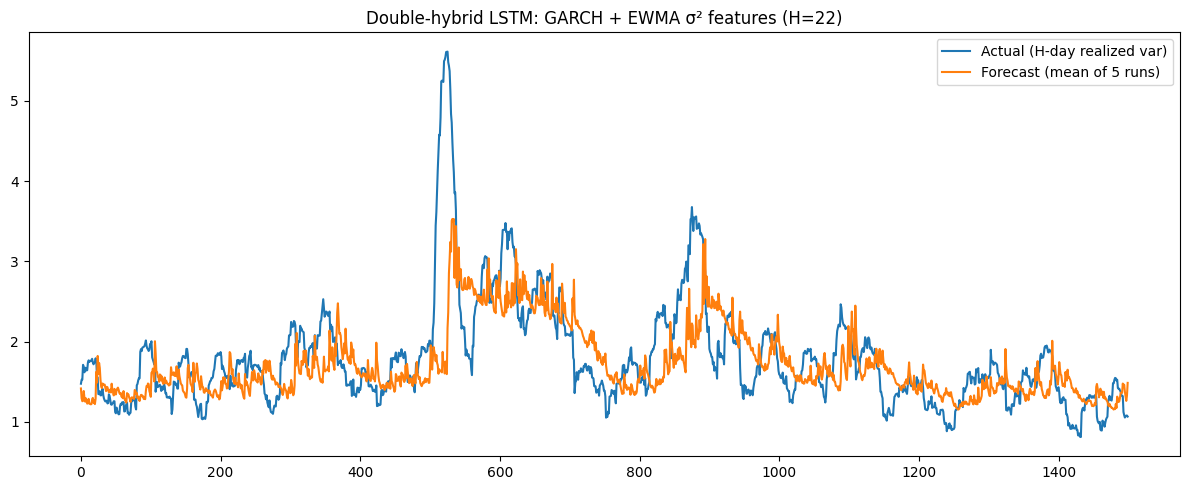

In [105]:
# ============================
# Double-hybrid LSTM: GARCH + EWMA
# ============================

Xtr, ytr_log, idx_tr = make_seq_dataset_double_hybrid(
    r_train, y_train,
    GARCH_VAR_FEATURE.loc[r_train.index],
    EWMA_VAR_FEATURE.loc[r_train.index],
    LOOKBACK
)
Xte, yte_log, idx_te = make_seq_dataset_double_hybrid(
    r_test, y_test,
    GARCH_VAR_FEATURE.loc[r_test.index],
    EWMA_VAR_FEATURE.loc[r_test.index],
    LOOKBACK
)

mu = Xtr.mean(axis=(0,1), keepdims=True)
sd = Xtr.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_s = (Xtr - mu) / sd
Xte_s = (Xte - mu) / sd

dh_lstm_gw_runs, dh_lstm_gw_preds_log = [], []
n_features = Xtr_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_double_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_s, ytr_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    dh_lstm_gw_runs.append(m)
    dh_lstm_gw_preds_log.append(pd.Series(pred_log, index=idx_te, name=f"seed_{seed}"))

dh_lstm_gw_results = pd.DataFrame(dh_lstm_gw_runs)
print("Double-hybrid LSTM (GARCH + EWMA) per run:")
display(dh_lstm_gw_results)
print("\nMean/std:")
display(dh_lstm_gw_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

dh_lstm_gw_pred_log_mat = pd.concat(dh_lstm_gw_preds_log, axis=1)
dh_lstm_gw_pred_var_mean = np.exp(dh_lstm_gw_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_log, index=idx_te)).values, label="Actual (H-day realized var)")
plt.plot(dh_lstm_gw_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Double-hybrid LSTM: GARCH + EWMA σ² features (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


## LSTM: EWMA + EGARCH

Double-hybrid LSTM (EWMA + EGARCH) per run:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.315245,0.561467,0.367079,0.197578,0.061813,11
1,0.309774,0.556574,0.361730,0.195518,0.060800,22
2,0.314170,0.560509,0.361084,0.192990,0.059124,33
3,0.319377,0.565134,0.367057,0.194390,0.058300,44
4,0.304667,0.551966,0.359812,0.193556,0.058299,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.312647,0.559130,0.363352,0.194807,0.059667
std,0.005619,0.005032,0.003461,0.001818,0.001575


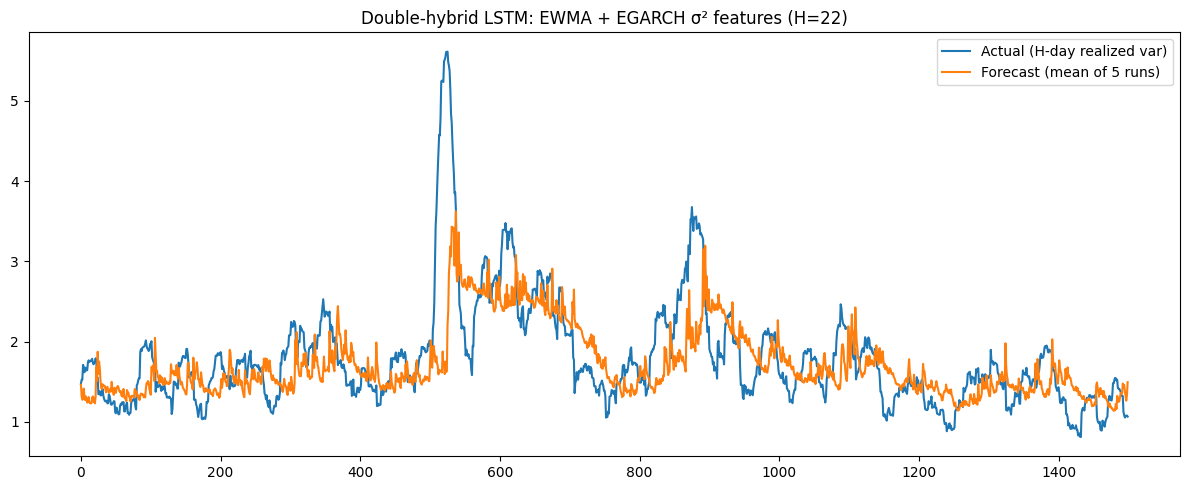

In [106]:
# ============================
# Double-hybrid LSTM: EWMA + EGARCH
# ============================

Xtr, ytr_log, idx_tr = make_seq_dataset_double_hybrid(
    r_train, y_train,
    EWMA_VAR_FEATURE.loc[r_train.index],
    EGARCH_VAR_FEATURE.loc[r_train.index],
    LOOKBACK
)
Xte, yte_log, idx_te = make_seq_dataset_double_hybrid(
    r_test, y_test,
    EWMA_VAR_FEATURE.loc[r_test.index],
    EGARCH_VAR_FEATURE.loc[r_test.index],
    LOOKBACK
)

mu = Xtr.mean(axis=(0,1), keepdims=True)
sd = Xtr.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_s = (Xtr - mu) / sd
Xte_s = (Xte - mu) / sd

dh_lstm_we_runs, dh_lstm_we_preds_log = [], []
n_features = Xtr_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_double_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(Xtr_s, ytr_log, validation_split=0.2,
              epochs=300, batch_size=256, verbose=0, callbacks=cb)

    pred_log = model.predict(Xte_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    dh_lstm_we_runs.append(m)
    dh_lstm_we_preds_log.append(pd.Series(pred_log, index=idx_te, name=f"seed_{seed}"))

dh_lstm_we_results = pd.DataFrame(dh_lstm_we_runs)
print("Double-hybrid LSTM (EWMA + EGARCH) per run:")
display(dh_lstm_we_results)
print("\nMean/std:")
display(dh_lstm_we_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

dh_lstm_we_pred_log_mat = pd.concat(dh_lstm_we_preds_log, axis=1)
dh_lstm_we_pred_var_mean = np.exp(dh_lstm_we_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_log, index=idx_te)).values, label="Actual (H-day realized var)")
plt.plot(dh_lstm_we_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Double-hybrid LSTM: EWMA + EGARCH σ² features (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


# Triple Hybrid LSTM

In [46]:
def make_seq_dataset_triple_hybrid(
    returns_series: pd.Series,
    y_var_series: pd.Series,
    feat_garch: pd.Series,
    feat_egarch: pd.Series,
    feat_ewma: pd.Series,
    lookback: int
):
    r = returns_series.astype(float)
    yv = y_var_series.astype(float)

    fg = feat_garch.reindex(r.index).astype(float)
    fe = feat_egarch.reindex(r.index).astype(float)
    fw = feat_ewma.reindex(r.index).astype(float)

    feats = pd.DataFrame({
        "r": r,
        "abs_r": np.abs(r),
        "r2": r**2,
        "log_r2": np.log(r**2 + EPS),
        "garch_var": fg,
        "egarch_var": fe,
        "ewma_var": fw,
    }).dropna()

    yv = yv.reindex(feats.index)
    data = feats.join(yv.rename("y_var")).dropna()

    X = data[["r","abs_r","r2","log_r2","garch_var","egarch_var","ewma_var"]].values.astype(np.float32)
    y = data["y_var"].values.astype(np.float32)
    idx = data.index

    X_list, y_list, idx_list = [], [], []
    for i in range(lookback - 1, len(data)):
        X_list.append(X[i - lookback + 1 : i + 1, :])
        y_list.append(np.log(float(y[i]) + EPS))
        idx_list.append(idx[i])

    X_seq = np.stack(X_list, axis=0)
    y_log = np.array(y_list, dtype=np.float32)
    idx_out = pd.Index(idx_list)
    return X_seq, y_log, idx_out


In [47]:
def build_triple_hybrid_lstm(lookback: int, n_features: int):
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.LSTM(64)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


Triple-hybrid LSTM (GARCH + EGARCH + EWMA) per run:


,MSE,RMSE,MAE,HMAE,HMSE,seed
0,0.310415,0.557149,0.360641,0.193501,0.059500,11
1,0.315889,0.562040,0.363712,0.195826,0.061581,22
2,0.313131,0.559581,0.365401,0.200191,0.066061,33
3,0.325707,0.570708,0.365559,0.192175,0.058047,44
4,0.304007,0.551368,0.363434,0.192757,0.056807,55



Mean/std:


,MSE,RMSE,MAE,HMAE,HMSE
mean,0.313830,0.560169,0.363749,0.194890,0.060399
std,0.007968,0.007097,0.001985,0.003272,0.003630


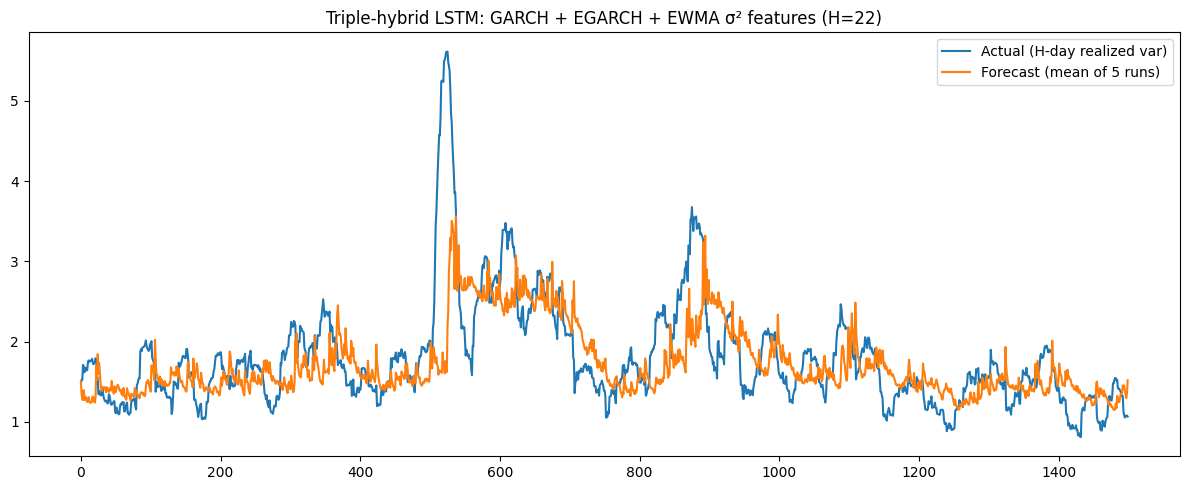

In [119]:
# =========================================
# Triple-hybrid LSTM: GARCH + EGARCH + EWMA
# =========================================

Xtr, ytr_log, idx_tr = make_seq_dataset_triple_hybrid(
    r_train, y_train,
    GARCH_VAR_FEATURE.loc[r_train.index],
    EGARCH_VAR_FEATURE.loc[r_train.index],
    EWMA_VAR_FEATURE.loc[r_train.index],
    LOOKBACK
)
Xte, yte_log, idx_te = make_seq_dataset_triple_hybrid(
    r_test, y_test,
    GARCH_VAR_FEATURE.loc[r_test.index],
    EGARCH_VAR_FEATURE.loc[r_test.index],
    EWMA_VAR_FEATURE.loc[r_test.index],
    LOOKBACK
)

mu = Xtr.mean(axis=(0,1), keepdims=True)
sd = Xtr.std(axis=(0,1), keepdims=True) + 1e-8
Xtr_s = (Xtr - mu) / sd
Xte_s = (Xte - mu) / sd

tri_lstm_runs, tri_lstm_preds_log = [], []
n_features = Xtr_s.shape[-1]

for seed in SEEDS:
    set_all_seeds(seed)

    model = build_triple_hybrid_lstm(LOOKBACK, n_features)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    model.fit(
        Xtr_s, ytr_log,
        validation_split=0.2,
        epochs=300,
        batch_size=256,
        verbose=0,
        callbacks=cb
    )

    pred_log = model.predict(Xte_s, verbose=0).reshape(-1)
    pred_var = np.maximum(np.exp(pred_log), EPS)
    true_var = np.exp(yte_log)

    m = metrics_vol(true_var, pred_var)
    m["seed"] = seed
    tri_lstm_runs.append(m)
    tri_lstm_preds_log.append(pd.Series(pred_log, index=idx_te, name=f"seed_{seed}"))

tri_lstm_results = pd.DataFrame(tri_lstm_runs)
print("Triple-hybrid LSTM (GARCH + EGARCH + EWMA) per run:")
display(tri_lstm_results)
print("\nMean/std:")
display(tri_lstm_results[["MSE","RMSE","MAE","HMAE","HMSE"]].agg(["mean","std"]))

tri_lstm_pred_log_mat = pd.concat(tri_lstm_preds_log, axis=1)
tri_lstm_pred_var_mean = np.exp(tri_lstm_pred_log_mat.mean(axis=1).values)

plt.figure(figsize=(12,5))
plt.plot(np.exp(pd.Series(yte_log, index=idx_te)).values, label="Actual (H-day realized var)")
plt.plot(tri_lstm_pred_var_mean, label="Forecast (mean of 5 runs)")
plt.title(f"Triple-hybrid LSTM: GARCH + EGARCH + EWMA σ² features (H={H})")
plt.legend()
plt.tight_layout()
plt.show()


In [122]:
def mean_pm_std(df, cols=("MSE","RMSE","MAE","HMAE","HMSE"), digits=4):
    """
    Returns a dict mapping metric -> 'mean ± std' strings for a results df
    that has one row per run/seed.
    """
    out = {}
    for c in cols:
        mu = float(df[c].mean())
        sd = float(df[c].std(ddof=1))
        out[c] = f"{mu:.{digits}f} ± {sd:.{digits}f}"
    return out


model_results_map = {
    # Univariate classical
    "EWMA": ewma_results,
    "GARCH(1,1)": garch_results,
    "EGARCH(1,1,o=1)": egarch_results,

    # Univariate NNs
    "MLP (uni)": mlp_results,
    "SimpleRNN (uni)": rnn_results,
    "LSTM (uni)": lstm_results,

    # Hybrid RNNs
    "Hybrid RNN + GARCH σ²": hyb_rnn_garch_results,
    "Hybrid RNN + EGARCH σ²": hyb_rnn_egarch_results,
    "Hybrid RNN + EWMA σ²": hyb_rnn_ewma_results,

    "Hybrid LSTM + GARCH σ²": hyb_lstm_garch_results,
    "Hybrid LSTM + EGARCH σ²": hyb_lstm_egarch_results,
    "Hybrid LSTM + EWMA σ²": hyb_lstm_ewma_results,

    "GE LSTM (GARCH+EGARCH)": dh_lstm_ge_results,
    "GW LSTM (GARCH+EWMA)": dh_lstm_gw_results,
    "WE LSTM (EWMA+EGARCH)": dh_lstm_we_results,

    "GWE LSTM(GARCH+EGARCH+EWMA)": tri_lstm_results,


}

rows = []
for name, df_res in model_results_map.items():
    if df_res is None:
        continue
    # Guard: skip if variable not defined / empty
    try:
        if len(df_res) == 0:
            continue
    except Exception:
        continue

    d = {"Model": name}
    d.update(mean_pm_std(df_res))
    rows.append(d)

summary_table = pd.DataFrame(rows).set_index("Model")

# Optional: sort by QLIKE mean (extract numeric mean)
def to_string_mean(s):
    # expects "mean ± std"
    return float(str(s).split("±")[0].strip())

summary_table_sorted = summary_table.copy()
summary_table_sorted["MSE"] = summary_table_sorted["MSE"].apply(to_string_mean)
summary_table_sorted = summary_table_sorted.sort_values("MSE").drop(columns=["MSE"])

print("Summary table (mean ± std):")
display(summary_table_sorted)

print("\n--- Copy/paste friendly (markdown) ---")
print(summary_table_sorted.to_markdown())


Summary table (mean ± std):


,RMSE,MAE,HMAE,HMSE
Model,,,,
GE LSTM (GARCH+EGARCH),0.5584 ± 0.0059,0.3618 ± 0.0034,0.1929 ± 0.0024,0.0589 ± 0.0021
WE LSTM (EWMA+EGARCH),0.5591 ± 0.0050,0.3634 ± 0.0035,0.1948 ± 0.0018,0.0597 ± 0.0016
GWE LSTM(GARCH+EGARCH+EWMA),0.5602 ± 0.0071,0.3637 ± 0.0020,0.1949 ± 0.0033,0.0604 ± 0.0036
Hybrid LSTM + EGARCH σ²,0.5626 ± 0.0080,0.3661 ± 0.0056,0.1949 ± 0.0044,0.0603 ± 0.0037
GW LSTM (GARCH+EWMA),0.5628 ± 0.0049,0.3674 ± 0.0027,0.1962 ± 0.0034,0.0601 ± 0.0026
Hybrid LSTM + GARCH σ²,0.5639 ± 0.0093,0.3670 ± 0.0074,0.1951 ± 0.0035,0.0598 ± 0.0025
LSTM (uni),0.5659 ± 0.0107,0.3712 ± 0.0063,0.1968 ± 0.0054,0.0607 ± 0.0034
Hybrid LSTM + EWMA σ²,0.5726 ± 0.0156,0.3742 ± 0.0108,0.1989 ± 0.0044,0.0623 ± 0.0029
Hybrid RNN + GARCH σ²,0.5779 ± 0.0036,0.3767 ± 0.0052,0.1981 ± 0.0049,0.0622 ± 0.0030



--- Copy/paste friendly (markdown) ---
| Model                       | RMSE            | MAE             | HMAE            | HMSE            |
|:----------------------------|:----------------|:----------------|:----------------|:----------------|
| GE LSTM (GARCH+EGARCH)      | 0.5584 ± 0.0059 | 0.3618 ± 0.0034 | 0.1929 ± 0.0024 | 0.0589 ± 0.0021 |
| WE LSTM (EWMA+EGARCH)       | 0.5591 ± 0.0050 | 0.3634 ± 0.0035 | 0.1948 ± 0.0018 | 0.0597 ± 0.0016 |
| GWE LSTM(GARCH+EGARCH+EWMA) | 0.5602 ± 0.0071 | 0.3637 ± 0.0020 | 0.1949 ± 0.0033 | 0.0604 ± 0.0036 |
| Hybrid LSTM + EGARCH σ²     | 0.5626 ± 0.0080 | 0.3661 ± 0.0056 | 0.1949 ± 0.0044 | 0.0603 ± 0.0037 |
| GW LSTM (GARCH+EWMA)        | 0.5628 ± 0.0049 | 0.3674 ± 0.0027 | 0.1962 ± 0.0034 | 0.0601 ± 0.0026 |
| Hybrid LSTM + GARCH σ²      | 0.5639 ± 0.0093 | 0.3670 ± 0.0074 | 0.1951 ± 0.0035 | 0.0598 ± 0.0025 |
| LSTM (uni)                  | 0.5659 ± 0.0107 | 0.3712 ± 0.0063 | 0.1968 ± 0.0054 | 0.0607 ± 0.0034 |
| Hybrid LSTM + EWMA σ² 

# Diebold Marino test

In [133]:
MODEL_ORDER = [
    "GARCH(1,1)",

    "MLP (uni)",
    "SimpleRNN (uni)",
    "LSTM (uni)",

    "Hybrid RNN + GARCH σ²",
    "Hybrid RNN + EGARCH σ²",
    "Hybrid RNN + EWMA σ²",

    "Hybrid LSTM + GARCH σ²",
    "Hybrid LSTM + EGARCH σ²",
    "Hybrid LSTM + EWMA σ²",

    "GE LSTM (GARCH+EGARCH)"
]


In [134]:
LOSS_COL = "HMSE"

loss_map = {
    model: model_results_map[model][LOSS_COL].values
    for model in MODEL_ORDER
}


In [135]:
def diebold_mariano(loss1, loss2):
    d = loss1 - loss2
    d = d[~np.isnan(d)]
    T = len(d)

    dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / T)
    p_value = 2 * (1 - stats.t.cdf(abs(dm_stat), df=T-1))
    return dm_stat, p_value


In [136]:
dm_stat_mat = pd.DataFrame(
    index=MODEL_ORDER,
    columns=MODEL_ORDER,
    dtype=float
)

for m1 in MODEL_ORDER:
    for m2 in MODEL_ORDER:
        if m1 == m2:
            dm_stat_mat.loc[m1, m2] = 0.0
        else:
            dm_stat, _ = diebold_mariano(loss_map[m1], loss_map[m2])
            dm_stat_mat.loc[m1, m2] = dm_stat

display(dm_stat_mat)


,"GARCH(1,1)",MLP (uni),SimpleRNN (uni),LSTM (uni),Hybrid RNN + GARCH σ²,Hybrid RNN + EGARCH σ²,Hybrid RNN + EWMA σ²,Hybrid LSTM + GARCH σ²,Hybrid LSTM + EGARCH σ²,Hybrid LSTM + EWMA σ²,GE LSTM (GARCH+EGARCH)
"GARCH(1,1)",0.000000,53.575759,6.695282,19.525050,20.504713,13.924121,24.482858,27.126392,17.968224,21.284772,32.551727
MLP (uni),-53.575759,0.000000,-3.437452,1.494439,0.839049,0.030162,0.841918,2.502361,1.558227,0.776190,3.378784
SimpleRNN (uni),-6.695282,3.437452,0.000000,3.644896,5.950034,10.180007,6.054065,5.330133,6.118525,4.207368,5.873308
LSTM (uni),-19.525050,-1.494439,-3.644896,0.000000,-0.758672,-1.054319,-0.868019,0.473106,0.187959,-0.613285,0.953353
Hybrid RNN + GARCH σ²,-20.504713,-0.839049,-5.950034,0.758672,0.000000,-0.871785,-0.276257,1.527999,1.466261,-0.067568,2.412474
Hybrid RNN + EGARCH σ²,-13.924121,-0.030162,-10.180007,1.054319,0.871785,0.000000,0.941346,2.103864,1.962408,0.569254,2.688248
Hybrid RNN + EWMA σ²,-24.482858,-0.841918,-6.054065,0.868019,0.276257,-0.941346,0.000000,2.215736,2.103978,0.019988,3.616012
Hybrid LSTM + GARCH σ²,-27.126392,-2.502361,-5.330133,-0.473106,-1.527999,-2.103864,-2.215736,0.000000,-0.607938,-3.217176,3.303516
Hybrid LSTM + EGARCH σ²,-17.968224,-1.558227,-6.118525,-0.187959,-1.466261,-1.962408,-2.103978,0.607938,0.000000,-1.783866,1.666025
Hybrid LSTM + EWMA σ²,-21.284772,-0.776190,-4.207368,0.613285,0.067568,-0.569254,-0.019988,3.217176,1.783866,0.000000,4.449225


In [138]:
dm_pval_mat = pd.DataFrame(
    index=MODEL_ORDER,
    columns=MODEL_ORDER,
    dtype=float
)

for m1 in MODEL_ORDER:
    for m2 in MODEL_ORDER:
        if m1 == m2:
            dm_pval_mat.loc[m1, m2] = np.nan
        else:
            _, pval = diebold_mariano(loss_map[m1], loss_map[m2])
            dm_pval_mat.loc[m1, m2] = pval

display(dm_pval_mat.replace(np.nan, "0.00"))


,"GARCH(1,1)",MLP (uni),SimpleRNN (uni),LSTM (uni),Hybrid RNN + GARCH σ²,Hybrid RNN + EGARCH σ²,Hybrid RNN + EWMA σ²,Hybrid LSTM + GARCH σ²,Hybrid LSTM + EGARCH σ²,Hybrid LSTM + EWMA σ²,GE LSTM (GARCH+EGARCH)
"GARCH(1,1)",0.00,0.000001,0.002589,0.000041,0.000033,0.000154,0.000017,0.000011,0.000056,0.000029,0.000005
MLP (uni),0.000001,0.00,0.026355,0.209371,0.448659,0.977383,0.447226,0.066598,0.19418,0.480975,0.027817
SimpleRNN (uni),0.002589,0.026355,0.00,0.02187,0.004003,0.000524,0.003757,0.005965,0.003614,0.013615,0.004198
LSTM (uni),0.000041,0.209371,0.02187,0.00,0.490295,0.351209,0.434359,0.660799,0.860059,0.572845,0.394398
Hybrid RNN + GARCH σ²,0.000033,0.448659,0.004003,0.490295,0.00,0.432527,0.796037,0.201233,0.216461,0.949372,0.073358
Hybrid RNN + EGARCH σ²,0.000154,0.977383,0.000524,0.351209,0.432527,0.00,0.399826,0.103202,0.121219,0.599626,0.054758
Hybrid RNN + EWMA σ²,0.000017,0.447226,0.003757,0.434359,0.796037,0.399826,0.00,0.091043,0.103189,0.98501,0.022436
Hybrid LSTM + GARCH σ²,0.000011,0.066598,0.005965,0.660799,0.201233,0.103202,0.091043,0.00,0.576055,0.032367,0.029835
Hybrid LSTM + EGARCH σ²,0.000056,0.19418,0.003614,0.860059,0.216461,0.121219,0.103189,0.576055,0.00,0.149012,0.171038
Hybrid LSTM + EWMA σ²,0.000029,0.480975,0.013615,0.572845,0.949372,0.599626,0.98501,0.032367,0.149012,0.00,0.011253
